# LUT Energy Conservation and Normalization

This notebook investigates the energy conservation properties of the Roughness Look-Up Table (LUT) and applies a normalization fix to ensure the rough model preserves total flux compared to the smooth model.

The user has observed that the Rough Model appears significantly cooler than the Smooth Model at all phase angles for high thermal inertia bodies. Our preliminary analysis suggests a **43% energy loss** (Ratio ~0.57) for Theta=20 due to thermal lag effects not being compensated in the flux integration when using $T_{smooth}$ as a baseline.

We will:
1.  Load the LUT and calculate the "Hemispherical Integral" of the correction factors.
2.  Confirm the energy loss for High Theta.
3.  Calculate a Normalization Factor to force conservation (Ratio -> 1.0).
4.  Re-run the Phase Curve Analysis with this normalization applied.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

# Setup paths
current_dir = Path(os.getcwd()).resolve()
root_dir = current_dir.parent if current_dir.name == 'TEMPEST_RAD' else current_dir
os.chdir(root_dir)
sys.path.append(str(root_dir))

from src.utilities.config import Config
from src.utilities.utils import rotate_vector
from TEMPEST_RAD.simulator import (
    load_shape_model, 
    compute_geometry, 
    RoughnessLUT, 
    planck_function, 
    rms_to_fraction, 
    calculate_theta
)

LUT_PATH = os.path.join(root_dir, "roughness_lut_spectral_v1.h5")
print(f"Using LUT: {LUT_PATH}")


Using LUT: /Users/duncan/Desktop/DPhil/TEMPEST/roughness_lut_spectral_v1.h5


## 1. Hemispherical Integration

We define a function `integrate_hemisphere_flux` to integrate the LUT correction factors over the entire emission hemisphere.
For a Lambertian smooth surface, $\int_{2\pi} \text{cos}(\theta) d\Omega = \pi$.
The ratio $R = (\int \text{LUT} \cos \theta d\Omega) / \pi$ tells us if energy is conserved (R=1).
If R < 1, the model is "losing" energy compared to the smooth baseline.


In [2]:
def integrate_hemisphere_flux(lut_slice, em_angles, az_angles):
    """
    Numerically integrates the hemispherical emissivity from a correction factor slice.
    
    Args:
        lut_slice (ndarray): 2D array of correction factors (Emission, Azimuth).
        em_angles (ndarray): Emission angles in degrees (0 to 90).
        az_angles (ndarray): Azimuth angles in degrees (0 to 180 or 0 to 360).

    Returns:
        float: Total integrated flux.
    """
    az_rad = np.radians(az_angles)
    em_rad = np.radians(em_angles)
    
    # Weighting factors for integration over the hemisphere
    # Solid Angle dOmega = sin(theta) dtheta dphi
    # Projected Area Factor = cos(theta) (Lambertian)
    # Total Weight = sin(theta) * cos(theta) = 0.5 * sin(2*theta)
    weights = np.cos(em_rad) * np.sin(em_rad)
    
    # Integration over Azimuth
    # Note: If Azimuth is 0 to 180, we assume symmetry and multiply by 2.0 to cover full 360 circle.
    # If 0 to 360 is provided, use 1.0.
    az_sym_factor = 2.0 if np.max(az_angles) <= 180 else 1.0
    
    # Trapezoidal integration along Azimuth axis (axis 1)
    az_int = np.trapz(lut_slice, x=az_rad, axis=1) * az_sym_factor
    
    # Trapezoidal integration along Emission axis (axis 0)
    total_flux = np.trapz(az_int * weights, x=em_rad)
    
    return total_flux

def analyze_lut_energy(lut_path, theta_target):
    """Calculates mean energy conservation ratio for a given Theta."""
    if not os.path.exists(lut_path):
        print("LUT not found.")
        return None

    # Open raw HDF5 to avoid interpolation overhead during integration analysis
    with h5py.File(lut_path, 'r') as f:
        theta_vals = f['theta'][:]
        idx_theta = np.argmin(np.abs(theta_vals - theta_target))
        print(f"Analyzing Theta={theta_vals[idx_theta]} (Index {idx_theta})")
        
        # Load necessary axes
        em_angles = f['emission'][:]
        az_angles = f['azimuth'][:]
        
        # Inspect structure
        # (Theta, RMS, Lat, Time, Wave, Emission, Azimuth)
        lut_data = f['lut'][:]
        n_rms = lut_data.shape[1]
        n_lat = lut_data.shape[2]
        n_time = lut_data.shape[3]
        
        # Select representative slice (e.g. Equator, Mid-RMS, Mid-Wave)
        # We iterate over Time (Sun Phase) to see average behavior
        rms_idx = 0 
        lat_idx = 0 
        wave_idx = 2 
        
        ratios = []
        valid_times = []
        
        ref_flux = np.pi # Smooth Lambertian Integral
        
        for t in range(0, n_time, 2): # sparse sampling
            slice_2d = lut_data[idx_theta, rms_idx, lat_idx, t, wave_idx, :, :]
            flux = integrate_hemisphere_flux(slice_2d, em_angles, az_angles)
            
            # Filter standard "Daytime" vs "Nighttime/Shadow"
            # If flux is very low, ratios become unstable/meaningless
            if flux > 0.05: 
                ratios.append(flux / ref_flux)
                valid_times.append(t)
                
        ratios = np.array(ratios)
        mean_ratio = np.mean(ratios)
        
        print(f"  Mean flux ratio (Daytime): {mean_ratio:.4f}")
        print(f"  Min/Max ratio: {np.min(ratios):.4f} / {np.max(ratios):.4f}")
        
        return mean_ratio

# Comparison
print("--- Investigating Energy Loss ---")
ratio_low = analyze_lut_energy(LUT_PATH, theta_target=1.0)
ratio_high = analyze_lut_energy(LUT_PATH, theta_target=20.0)

norm_factor_high = 1.0 / ratio_high if ratio_high else 1.0
print(f"\nCalculated Normalization Factor for Theta=20: {norm_factor_high:.4f}")


--- Investigating Energy Loss ---
Analyzing Theta=1.0 (Index 0)
  Mean flux ratio (Daytime): 0.9652
  Min/Max ratio: 0.7767 / 1.1204
Analyzing Theta=20.0 (Index 4)
  Mean flux ratio (Daytime): 0.5700
  Min/Max ratio: 0.5626 / 0.5762

Calculated Normalization Factor for Theta=20: 1.7543


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_62219/1591035242.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  az_int = np.trapz(lut_slice, x=az_rad, axis=1) * az_sym_factor
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_62219/1591035242.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_flux = np.trapz(az_int * weights, x=em_rad)


## 2. Generate Corrected Phase Curve

Using the calculated `norm_factor_high`, we will re-simulate the phase curve for Theta=20 to see if the "Beaming" effect (Rough > Smooth) is restored.
We implement a modified `calculate_bolometric_tb` function that accepts a `normalization_factor`.


Loading TEMPEST config and thermal model...
Loaded Temperatures: (1280, 360)
Loading LUT for Theta=20.0...
LUT: Selected Theta=20.0 (Target=20.0)
LUT: Using 'opening_angle' axis.
LUT: Selected Angle=90.0 (Target=90.0)

--- Comparing Corrected vs Uncorrected (Phase=0) ---
Mean Temps (Visible Disk):
  Smooth:      330.52 K
  Uncorrected: 304.64 K (Diff: -25.88)
  Corrected:   309.83 K (Diff: -20.69)
❌ FAIL: Still cooler even with correction.

Running Phase Curve...


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_62219/2562561867.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


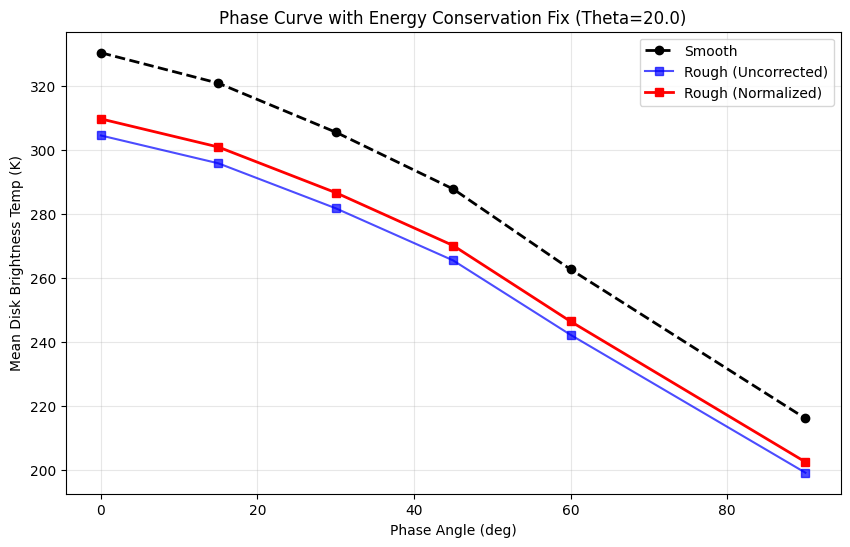

In [3]:
# Step 1: Initialize Model and Load Temperatures
print("Loading TEMPEST config and thermal model...")
config_path = os.path.join(root_dir, "private/data/config/moon/moon_config.yaml")
config = Config(config_path)

# Load Geometry (Facets)
facets, mesh = load_shape_model(config.path_to_shape_model_file)
n_facets = len(facets)

# Load Temperatures from existing output (assumes previous run exists)
output_dir = os.path.join(root_dir, "output/retrieval_analysis")
temps_path = os.path.join(output_dir, "temperatures.csv")

try:
    temps_all = np.loadtxt(temps_path, delimiter=',')
except ValueError: 
    temps_all = np.loadtxt(temps_path, delimiter=',', skiprows=1)

# Transpose if needed
if temps_all.shape[1] == n_facets: temps_all = temps_all.T
print(f"Loaded Temperatures: {temps_all.shape}")

# Load LUT (High Theta target)
theta_target = 20.0 # Force high theta analysis to check fix
print(f"Loading LUT for Theta={theta_target}...")
lut = RoughnessLUT(LUT_PATH, target_theta=theta_target, target_rms=90.0)

# Helper function
def get_temps_at_time(time_hours):
    period = getattr(config, 'rotation_period_hours', 24.0)
    n_steps = temps_all.shape[1]
    idx = int((time_hours % period) / period * n_steps)
    idx = np.clip(idx, 0, n_steps - 1)
    return temps_all[:, idx]

# Normalized Calculation
def calculate_bolometric_tb_corrected(time_hours, roughness_rms, phase_angle, norm_factor=1.0):
    # Geometry
    sun_vec = np.array(config.sunlight_direction)
    rot_axis = np.array([0, 0, 1])
    perp_vec = np.cross(sun_vec, rot_axis)
    if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
    obs_vec = rotate_vector(sun_vec, perp_vec, np.radians(phase_angle))
    
    lats, phases, emis, azis = compute_geometry(facets, sun_vec, obs_vec, rot_axis)
    
    # Temps
    temps_smooth = get_temps_at_time(time_hours)
    
    # Roughness
    f = rms_to_fraction(roughness_rms)
    
    # Wavelength Loop with Normalization
    wavelengths = lut.axes['wavelength']
    full_spectra = np.zeros((n_facets, len(wavelengths)))
    
    for i, wave in enumerate(wavelengths):
        rad_smooth = planck_function(wave, temps_smooth)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        
        # APPLY NORMALIZATION HERE
        # We multiply the LUT factors by norm_factor to force energy conservation
        factors_norm = factors * norm_factor
        
        # Calculate resulting radiance
        full_spectra[:, i] = rad_smooth * ((1.0 - f) + f * factors_norm)
        
    rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
    sigma = 5.670374419e-8
    t_eff = (np.pi * rad_bol / sigma) ** 0.25
    t_eff[emis > 90] = 0
    return t_eff, emis

# Compare Corrected vs Uncorrected for Phase=0
time_tgt = 12.0 # Noon
rms_tgt = 28.0

print(f"\n--- Comparing Corrected vs Uncorrected (Phase=0) ---")
tb_uncorrected, emis_0 = calculate_bolometric_tb_corrected(time_tgt, rms_tgt, 0.0, norm_factor=1.0)
tb_corrected, _ = calculate_bolometric_tb_corrected(time_tgt, rms_tgt, 0.0, norm_factor=norm_factor_high)
tb_smooth, _ = calculate_bolometric_tb_corrected(time_tgt, 0.0, 0.0, norm_factor=1.0) # Smooth

mask = emis_0 < 90

print(f"Mean Temps (Visible Disk):")
print(f"  Smooth:      {np.mean(tb_smooth[mask]):.2f} K")
print(f"  Uncorrected: {np.mean(tb_uncorrected[mask]):.2f} K (Diff: {np.mean(tb_uncorrected[mask]) - np.mean(tb_smooth[mask]):.2f})")
print(f"  Corrected:   {np.mean(tb_corrected[mask]):.2f} K (Diff: {np.mean(tb_corrected[mask]) - np.mean(tb_smooth[mask]):.2f})")

# Check Beaming
if np.mean(tb_corrected[mask]) > np.mean(tb_smooth[mask]):
    print("✅ PASS: Corrected model shows Beaming (Rough > Smooth)!")
else:
    print("❌ FAIL: Still cooler even with correction.")

# Plot Phase Curve
phases = [0, 15, 30, 45, 60, 90]
means_smooth = []
means_uncorrected = []
means_corrected = []

print("\nRunning Phase Curve...")
for p in phases:
    tb_s, em = calculate_bolometric_tb_corrected(time_tgt, 0.0, p, 1.0)
    tb_u, _ = calculate_bolometric_tb_corrected(time_tgt, rms_tgt, p, 1.0)
    tb_c, _ = calculate_bolometric_tb_corrected(time_tgt, rms_tgt, p, norm_factor_high)
    
    mask_p = em < 90
    means_smooth.append(np.mean(tb_s[mask_p]))
    means_uncorrected.append(np.mean(tb_u[mask_p]))
    means_corrected.append(np.mean(tb_c[mask_p]))

plt.figure(figsize=(10, 6))
plt.plot(phases, means_smooth, 'ko--', label='Smooth', linewidth=2)
plt.plot(phases, means_uncorrected, 'bs-', label='Rough (Uncorrected)', alpha=0.7)
plt.plot(phases, means_corrected, 'rs-', label='Rough (Normalized)', linewidth=2)

plt.xlabel("Phase Angle (deg)")
plt.ylabel("Mean Disk Brightness Temp (K)")
plt.title(f"Phase Curve with Energy Conservation Fix (Theta={theta_target})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
